### Global Configuration for Word Analysis

In [112]:
#Configure Target Word and Decades
query_word = "love" # @param {type:"string"}
decade1 = 1830 # @param {type:"integer"}
decade2 = 1930 # @param {type:"integer"}




---



## Extract year from filename

In [113]:
def extract_year_and_decade(filename):
    """Extracts the 4-digit year and calculates the decade from a filename."""
    year_match = re.search(r'fic_(\d{4})_', filename)
    if year_match:
        year = int(year_match.group(1))
        decade = (year // 10) * 10
        return year, decade
    return None, None

In [114]:
import os
import re
import glob
from collections import defaultdict

COHA_GLOB = "/content/*.txt"
file_paths = sorted(glob.glob(COHA_GLOB))

#dictionary to store docs by decade
decade_docs = defaultdict(list)

#loop through all corpus files
for fp in file_paths:

    filename = os.path.basename(fp)

    # Use the helper function to extract year and decade
    year, decade = extract_year_and_decade(filename)

    # if a decade is found
    if decade is not None:
        print(filename, "→", decade)

fic_1817_8550.txt → 1810
fic_1827_8950.txt → 1820
fic_1830_8750.txt → 1830
fic_1831_8850.txt → 1830
fic_1836_7350.txt → 1830
fic_1836_8650.txt → 1830
fic_1838_7250.txt → 1830
fic_1845_7450.txt → 1840
fic_1847_7650.txt → 1840
fic_1868_9550.txt → 1860
fic_1873_5050.txt → 1870
fic_1874_2650.txt → 1870
fic_1874_9050.txt → 1870
fic_1877_9450.txt → 1870
fic_1883_2450.txt → 1880
fic_1884_9250.txt → 1880
fic_1888_4850.txt → 1880
fic_1889_2950.txt → 1880
fic_1890_4350.txt → 1890
fic_1896_3350.txt → 1890
fic_1896_9350.txt → 1890
fic_1897_850.txt → 1890
fic_1900_3850.txt → 1900
fic_1908_1150.txt → 1900
fic_1910_13150.txt → 1910
fic_1910_2750.txt → 1910
fic_1915_5250.txt → 1910
fic_1919_1550.txt → 1910
fic_1920_550.txt → 1920
fic_1930_23150.txt → 1930
fic_1933_23250.txt → 1930
fic_1933_5650.txt → 1930
fic_1934_10050.txt → 1930
fic_1937_23350.txt → 1930
fic_1938_16350.txt → 1930
fic_1941_10150.txt → 1940
fic_1941_780150.txt → 1940
fic_1942_13850.txt → 1940
fic_1943_23450.txt → 1940
fic_1946_1050.tx

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Tools for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set Seaborn plot style globally for consistent plotting
sns.set_style("darkgrid")

In [116]:
def plot_trajectory(df, line_color, scatter_palette, title, xlabel, ylabel, text_prefix=''):
    """
    Plots a trajectory given a DataFrame with 'x', 'y', and 'decade' columns.

    Args:
        df (pd.DataFrame): DataFrame containing 'x', 'y' coordinates and 'decade' labels.
        line_color (str): Color for the line plot.
        scatter_palette (str): Color palette for the scatter plot.
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        text_prefix (str): Prefix for the text labels on each point (e.g., 'love ').
    """
    plt.figure(figsize=(12, 8))

    sns.lineplot(data=df, x='x', y='y', sort=False, marker='o', markersize=8, linewidth=2, color=line_color)
    sns.scatterplot(data=df, x='x', y='y', hue='decade', s=100, palette=scatter_palette, legend='full')

    for i, row in df.iterrows():
        plt.text(row['x'] + 0.1, row['y'], f"{text_prefix}{row['decade']}", fontsize=10, color='black', ha='left', va='center')

    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [117]:
def collect_word_vectors_across_decades(models, word):
    vectors = []
    labels = []

    for decade in sorted(models.keys()):
        if word in models[decade].wv:
            vectors.append(models[decade].wv[word])
            labels.append(f"{decade}s")

    return np.array(vectors), labels

## Group texts by decade



In [118]:
# Dictionary:
# key   = decade
# value = list of raw text segments
raw_docs_by_decade = defaultdict(list)

#loop through each COHA file
for fp in file_paths:

    # Get filename
    filename = os.path.basename(fp)

    # Use the helper function to extract year and decade
    year, decade = extract_year_and_decade(filename)

    # continue only if decade exists
    if decade is not None:

        #Open and read file
        with open(fp, encoding='utf-8', errors='replace') as f:
            content = f.read()

        #Split documents using COHA boundary markers
        parts = re.split(r'@@\d+', content)

        #Process each segment separately
        for part in parts:

            #Remove extra whitespace
            stripped = part.strip()

            #Ignore empty segments
            if stripped:

                #Store segment in the correct decade bucket
                raw_docs_by_decade[decade].append(stripped)

#print all detected decades
print(raw_docs_by_decade.keys())

dict_keys([1810, 1820, 1830, 1840, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000])


In [119]:
raw_docs_by_decade[1810]

['The author is indebted to one of the novels of Le Brun , for the ground-work of this little comedy . DRAMATIS PERSON . Philadelphia Count Almeyda Mr. Robertson Count Arandez Warren Carlos Wood Pacomo Jefferson Gusman Abercrombie Pedrillo Durang Herald Jackson Eugenia Mrs. Entwistle Beatrice Francis Flora Claude Ladies , knights , men-at-arms , pages , servants . SCENE  --  at the castle of count Almeyda in Catalonia , during the thirteenth century . Time  --  twenty-four hours . Main text ACT I. SCENE I  --  a thick wood . Carlos . Carlos ( entering ) Come along , Pacomo . Pacomo . Pacomo ( without ) Here I come , signor , as fast as the briers will permit me . ( Pacomo enters , dragging a large portmanteau ; he stops at the wing , looking ruefully around . ) No outlet yet , sir ? Car . Carlos None . Pac . Pacomo ( resting his portmanteau against a tree , and taking his seat upon it ) Why , then , sir , we might as well make up our minds to starve @ @ @ @ @ @ @ @ @ @ Carlos This is a

## Preprocess each decade separately

In [120]:
import spacy
import re

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.add_pipe('sentencizer')

def coha_preprocess(text: str) -> str:
    """Strip COHA markup and dramatic-text noise from a raw document string."""
    # 1. Remove redaction markers (space-separated @ symbols)
    text = re.sub(r'(?:@\s*)+', ' ', text)

    # 2. Remove stage directions in parentheses (including nested)
    text = re.sub(r'\([^)]*\)', ' ', text)

    # 3. Remove structural headers typical of COHA dramatic texts
    headers = [
        r'Main text', r'DRAMATIS PERSON\.?', r'ACT\s+[IVXLC]+\.?',
        r'SCENE\s+[IVXLC]+', r'SCENE\s+\w+', r'CHORUS',
        r'END\s+OF\s+ACT', r'STAGE DIRECTIONS', r'EXITS? AND ENTRANCES?',
        r'RELATIVE POSITIONS?',
    ]
    for h in headers:
        text = re.sub(h, ' ', text, flags=re.IGNORECASE)

    # 4. Remove character-name prefixes: "Carlos . Carlos" or "Eug . Eugenia"
    #    Pattern: short abbreviation, dot, full name (all followed by the speech)
    text = re.sub(r'\b[A-Z][a-z]{0,6}\s*\.\s*[A-Z][a-zA-Z]+\s+', ' ', text)

    # 5. Remove ALL-CAPS single words (stage direction labels like "Aside", "R.", "L.")
    text = re.sub(r'\b[A-Z]{2,}\b\.?', ' ', text)

    # 6. Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def spacy_clean(doc) -> list[str] | None:
    """Lemmatize and remove stopwords/punctuation. Returns None for very short docs."""
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and token.is_alpha and len(token.text) > 1
    ]
    if len(tokens) > 2:
        return tokens # Return list of tokens instead of a joined string
    return None

Convert cleaned texts to tokenized sentences

In [121]:
# key   = decade
# value = list of cleaned, tokenized sentences (strings)
cleaned_by_decade = {}

# Loop through each decade corpus
for decade, docs in raw_docs_by_decade.items():

    # Apply COHA-specific cleaning first. This retains punctuation needed for sentence detection.
    prepped_docs = [coha_preprocess(doc) for doc in docs]

    # Process these prepped documents with spaCy.
    # The `sentencizer` component (added in Dg5emOAvpT-D) will now detect sentences.
    spacy_doc_objects = nlp.pipe(prepped_docs, batch_size=200)

    all_cleaned_sentences_for_decade = []

    for spacy_doc in spacy_doc_objects:
        # Iterate over sentences within each spaCy Doc object
        for sent in spacy_doc.sents:
            # Apply spacy_clean to each sentence (which is a spaCy Span object)
            cleaned_sent_string = spacy_clean(sent)
            if cleaned_sent_string: # Only add if spacy_clean returns a non-empty string
                all_cleaned_sentences_for_decade.append(cleaned_sent_string)

    # Store the list of cleaned sentence strings for the current decade
    cleaned_by_decade[decade] = all_cleaned_sentences_for_decade

    # Print summary (now this is the actual sentence count)
    print(decade, "→", len(all_cleaned_sentences_for_decade), "sentences")

1810 → 665 sentences
1820 → 332 sentences
1830 → 4981 sentences
1840 → 733 sentences
1860 → 265 sentences
1870 → 8021 sentences
1880 → 9571 sentences
1890 → 6248 sentences
1900 → 4503 sentences
1910 → 6107 sentences
1920 → 4950 sentences
1930 → 5957 sentences
1940 → 7342 sentences
1950 → 2343 sentences
1960 → 6933 sentences
1970 → 10027 sentences
1980 → 2654 sentences
1990 → 2499 sentences
2000 → 6482 sentences


## Train one model per decade

In [122]:
!pip install gensim
from gensim.models import Word2Vec
# key   = decade
# value = trained Word2Vec model
models = {}

# Loop through each decade corpus
for decade, sentences in cleaned_by_decade.items():

    print(f"\nTraining model for {decade}s")

    # Train Word2Vec model
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,   # embedding dimensions
        window=5,          # context window size
        min_count=3,       # ignore words appearing < 3 times
        workers=2,         # CPU threads
        epochs=30          # training iterations
    )

    # Store model
    models[decade] = model


Training model for 1810s

Training model for 1820s

Training model for 1830s

Training model for 1840s

Training model for 1860s

Training model for 1870s

Training model for 1880s

Training model for 1890s

Training model for 1900s

Training model for 1910s

Training model for 1920s

Training model for 1930s

Training model for 1940s

Training model for 1950s

Training model for 1960s

Training model for 1970s

Training model for 1980s

Training model for 1990s

Training model for 2000s


In [123]:
#Example - access each decade model separately
models[1810]
models[1820]
models[1830]

In [124]:
# Example: query nearest neighbors for a word

models[1810].wv.most_similar("love")

[('almeyda', 0.9992180466651917),
 ('woman', 0.9992067813873291),
 ('sex', 0.999203085899353),
 ('fine', 0.9991396069526672),
 ('court', 0.9991251826286316),
 ('count', 0.9991173148155212),
 ('eugenia', 0.9990920424461365),
 ('arandez', 0.9990890026092529),
 ('son', 0.9990849494934082),
 ('man', 0.9990712404251099)]

Querying

In [125]:
# Loop through all trained decade models
for decade in sorted(models.keys()):

    print(f"\n--- {decade}s ---")

    # Find most similar words to "love"
    if "love" in models[decade].wv:
        results = models[decade].wv.most_similar("love", topn=5)

        # Print results neatly
        for word, score in results:
            print(word, round(score, 3))
    else:
        # Handle missing vocabulary
        print("'love' not in vocabulary")


--- 1810s ---
almeyda 0.999
woman 0.999
sex 0.999
fine 0.999
court 0.999

--- 1820s ---
head 0.999
tancre 0.999
run 0.999
voice 0.999
refuse 0.999

--- 1830s ---
mother 0.924
heart 0.906
dost 0.902
canst 0.892
wert 0.891

--- 1840s ---
life 0.999
dream 0.999
seek 0.998
afar 0.998
th 0.998

--- 1860s ---
old 0.976
jeff 0.975
young 0.975
dat 0.975
de 0.973

--- 1870s ---
happy 0.868
angel 0.867
pure 0.861
devil 0.85
noble 0.836

--- 1880s ---
friendship 0.755
suffer 0.714
true 0.702
soul 0.682
sympathy 0.681

--- 1890s ---
dearly 0.926
die 0.877
dear 0.86
jerusalem 0.832
happy 0.82

--- 1900s ---
affair 0.763
garret 0.745
father 0.734
anybody 0.717
everybody 0.708

--- 1910s ---
son 0.942
husband 0.915
understand 0.899
god 0.899
learn 0.896

--- 1920s ---
mother 0.939
good 0.904
daughter 0.886
ve 0.874
father 0.869

--- 1930s ---
happen 0.925
year 0.917
remember 0.916
pride 0.915
silly 0.91

--- 1940s ---
sister 0.922
different 0.917
marry 0.916
married 0.915
fellow 0.914

--- 1950s ---

### Word Similarity Across Decades

In [126]:
# Helper function to show similar words from a specific model
def show_similar_for_decade(model, word, topn=10):
    try:
        results = model.wv.most_similar(positive=[word], topn=topn)
        for w, score in results:
            print(f"  {w:<20} {score:.4f}")
    except KeyError:
        print(f"'{word}' not in vocabulary for this decade.")

# Define the target word for similarity comparison across decades
target_word_for_decades = query_word

# Loop through each trained decade model
for decade in sorted(models.keys()):
    print(f"\nMost similar to '{target_word_for_decades}' in {decade}s:")
    show_similar_for_decade(models[decade], target_word_for_decades)



Most similar to 'love' in 1810s:
  almeyda              0.9992
  woman                0.9992
  sex                  0.9992
  fine                 0.9991
  court                0.9991
  count                0.9991
  eugenia              0.9991
  arandez              0.9991
  son                  0.9991
  man                  0.9991

Most similar to 'love' in 1820s:
  head                 0.9989
  tancre               0.9988
  run                  0.9988
  voice                0.9988
  refuse               0.9987
  let                  0.9987
  shall                0.9987
  bright               0.9987
  holy                 0.9987
  bear                 0.9987

Most similar to 'love' in 1830s:
  mother               0.9236
  heart                0.9061
  dost                 0.9023
  canst                0.8920
  wert                 0.8909
  girl                 0.8907
  art                  0.8896
  nay                  0.8882
  wife                 0.8862
  bless                0.885

## Most Frequent Tokens Per Decade

/tmp/ipykernel_1507/415847947.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_1507/415847947.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_1507/415847947.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_1507/415847947.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

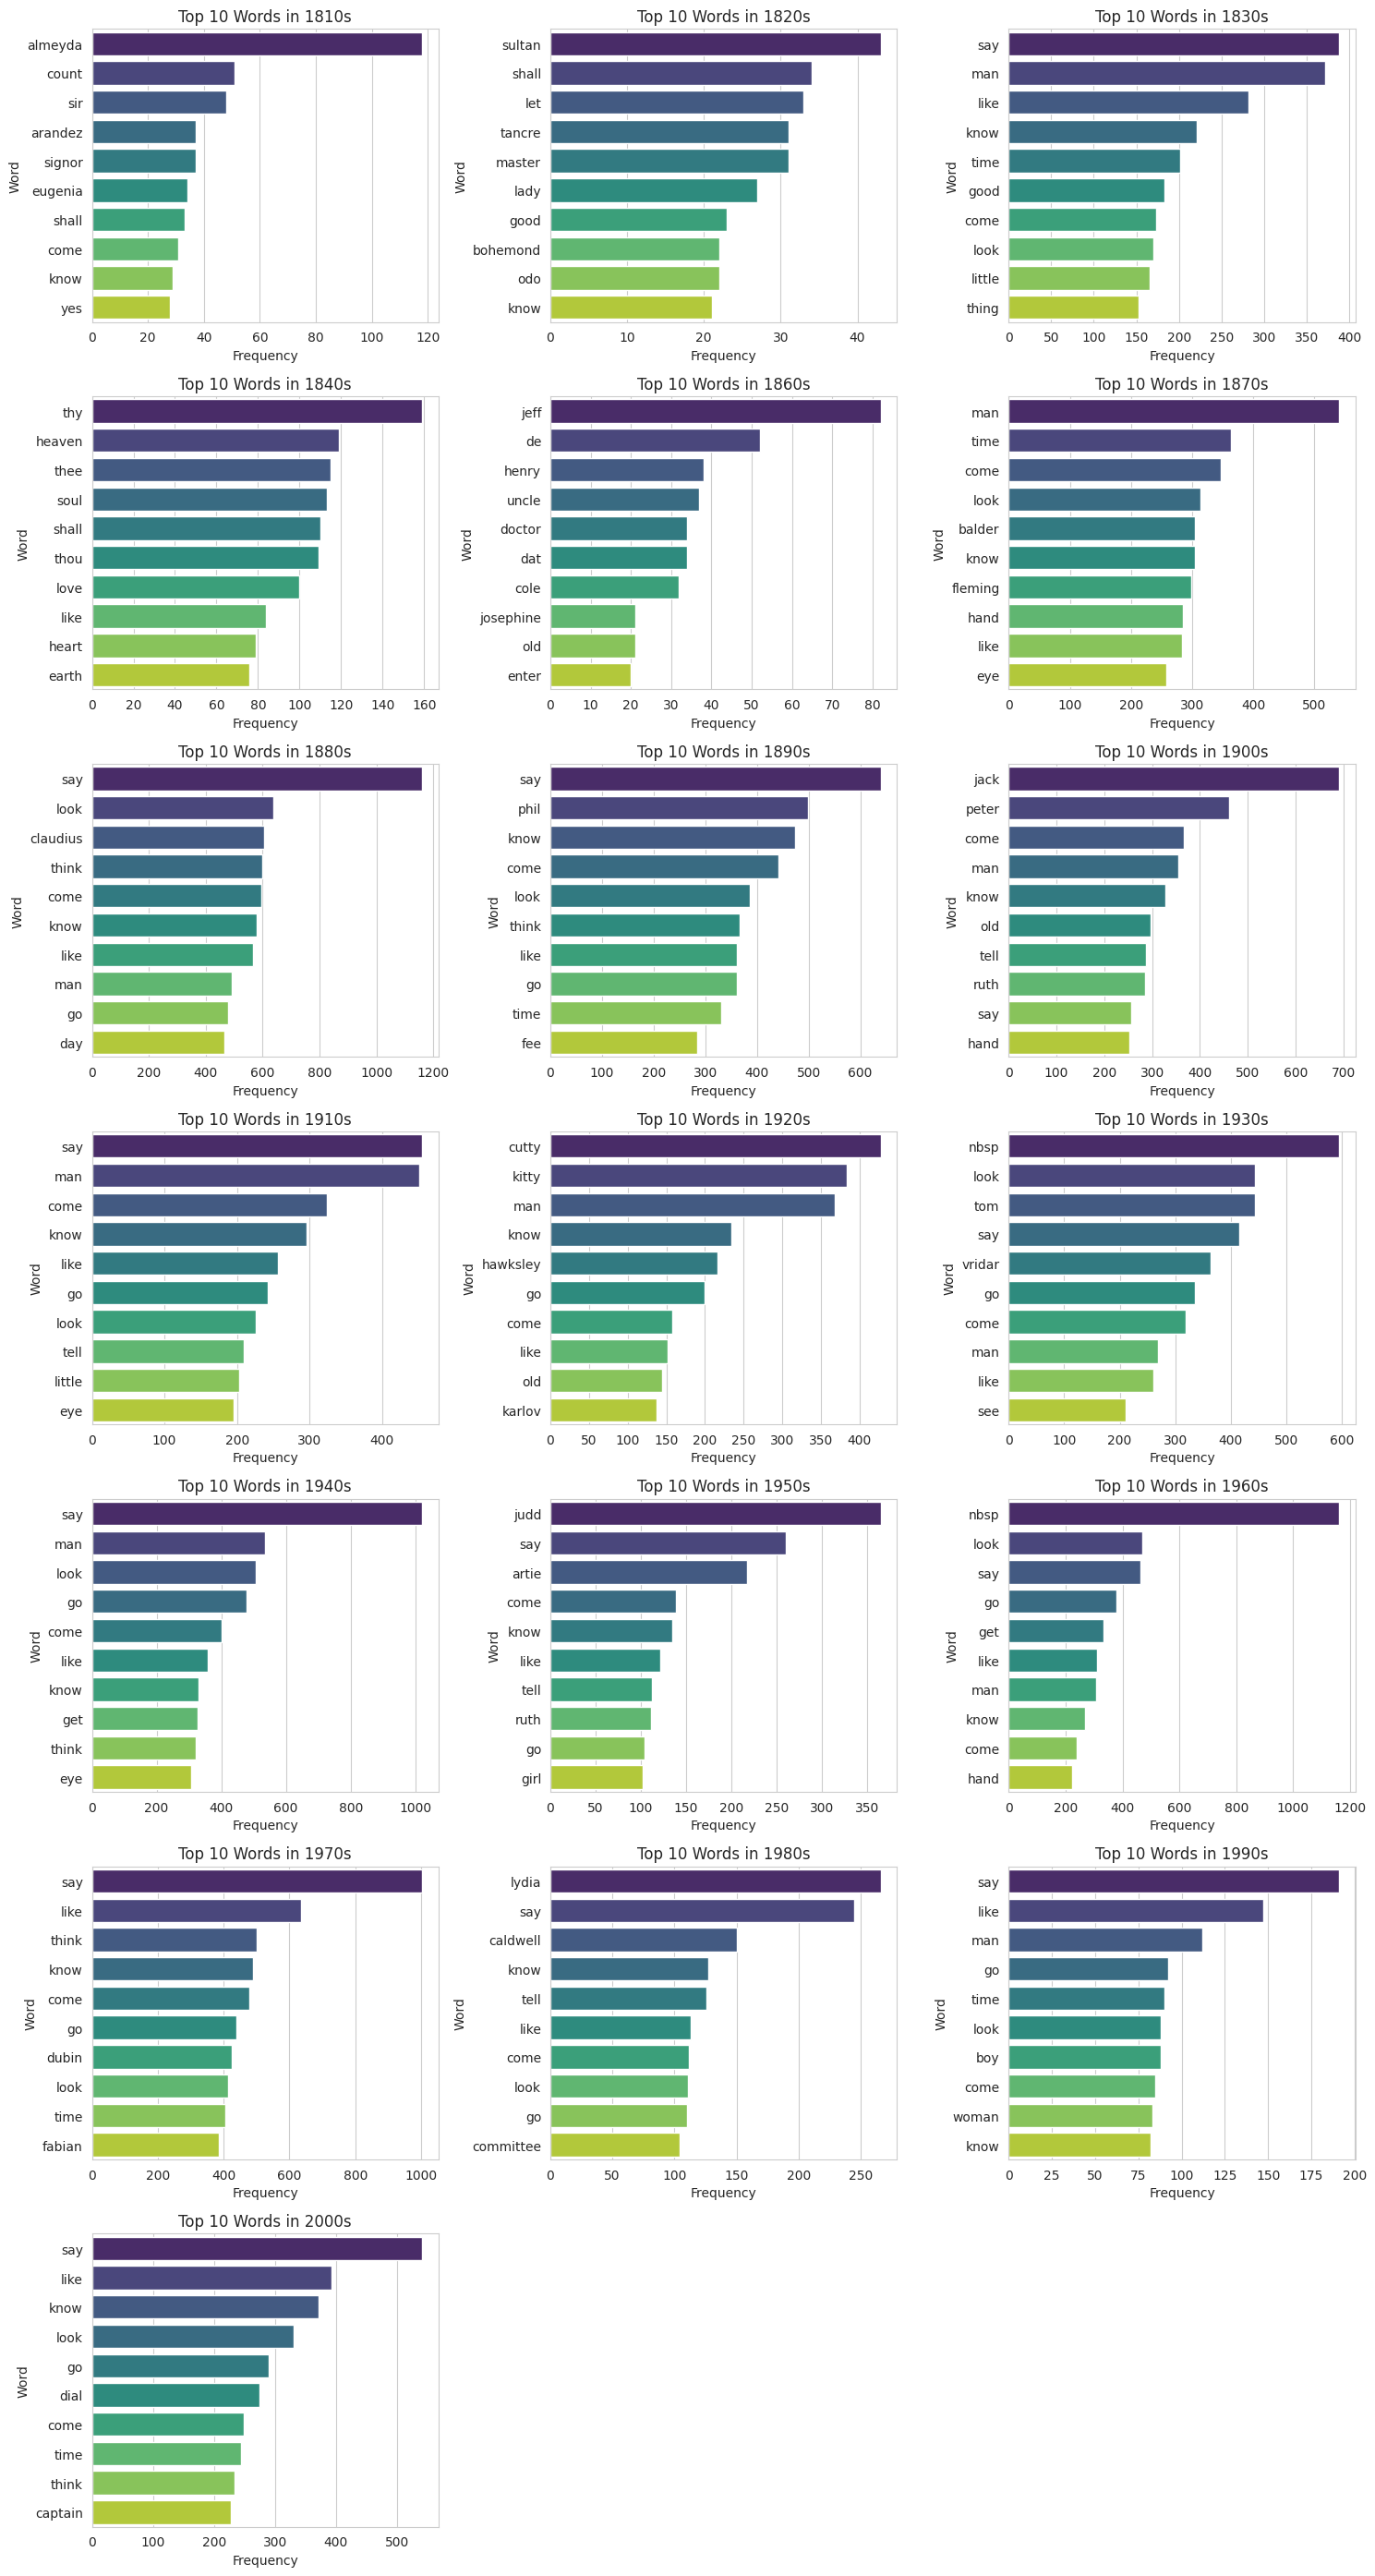

In [127]:
from collections import Counter

# Set up the plotting style
sns.set_style("whitegrid")

# Determine the number of decades to plot to set up a grid
num_decades = len(cleaned_by_decade)
n_cols = 3 # Number of columns for subplots
n_rows = (num_decades + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, (decade, sentences) in enumerate(cleaned_by_decade.items()):
    # Flatten the list of lists (sentences) into a single list of words
    all_words = [word for sentence in sentences for word in sentence]

    # Count word frequencies
    word_counts = Counter(all_words)

    # Get the top 10 most common words
    top_words = word_counts.most_common(10)

    if not top_words:
        ax.set_title(f'{decade}s: No words found')
        continue

    words, counts = zip(*top_words)

    # Plotting on the current subplot
    sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top 10 Words in {decade}s')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('Word')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## t-SNE Visualization: Comparing Word Clusters Across Decades

Comparing t-SNE clusters for 'love' between the 1830s and 1930s.


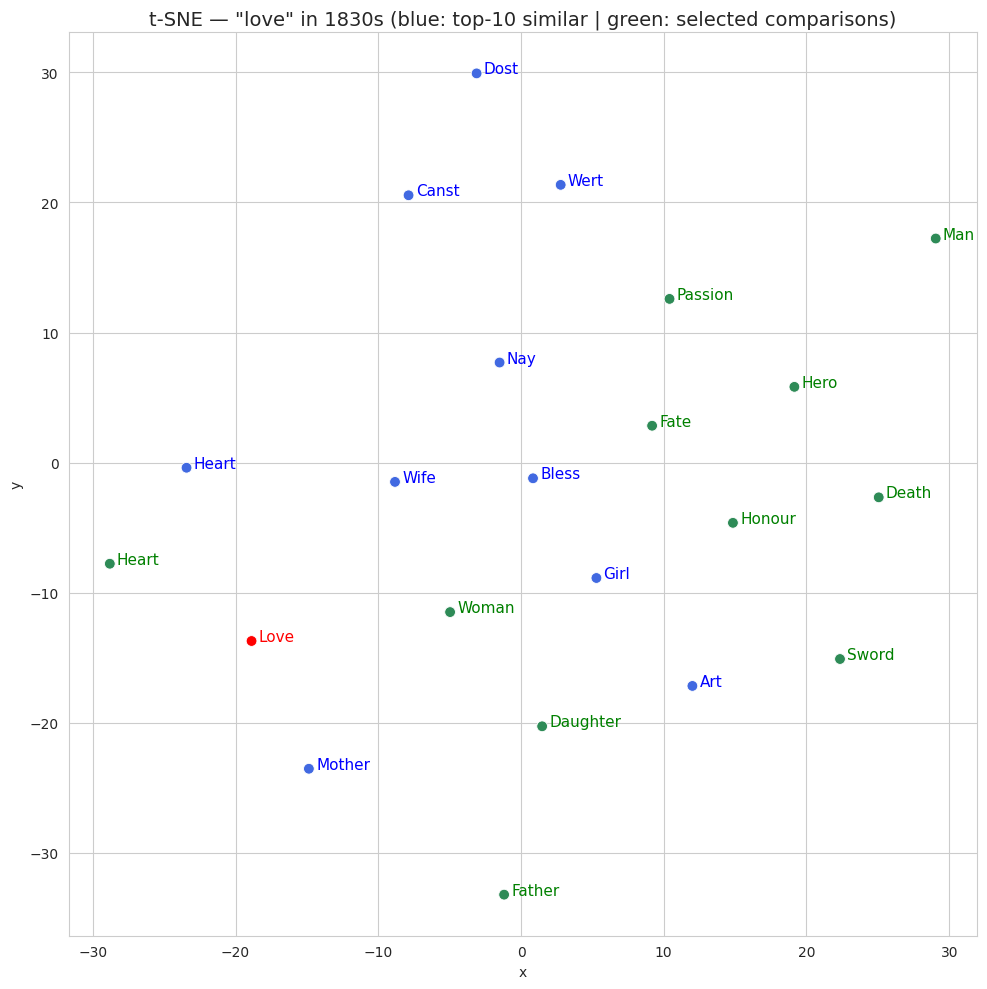

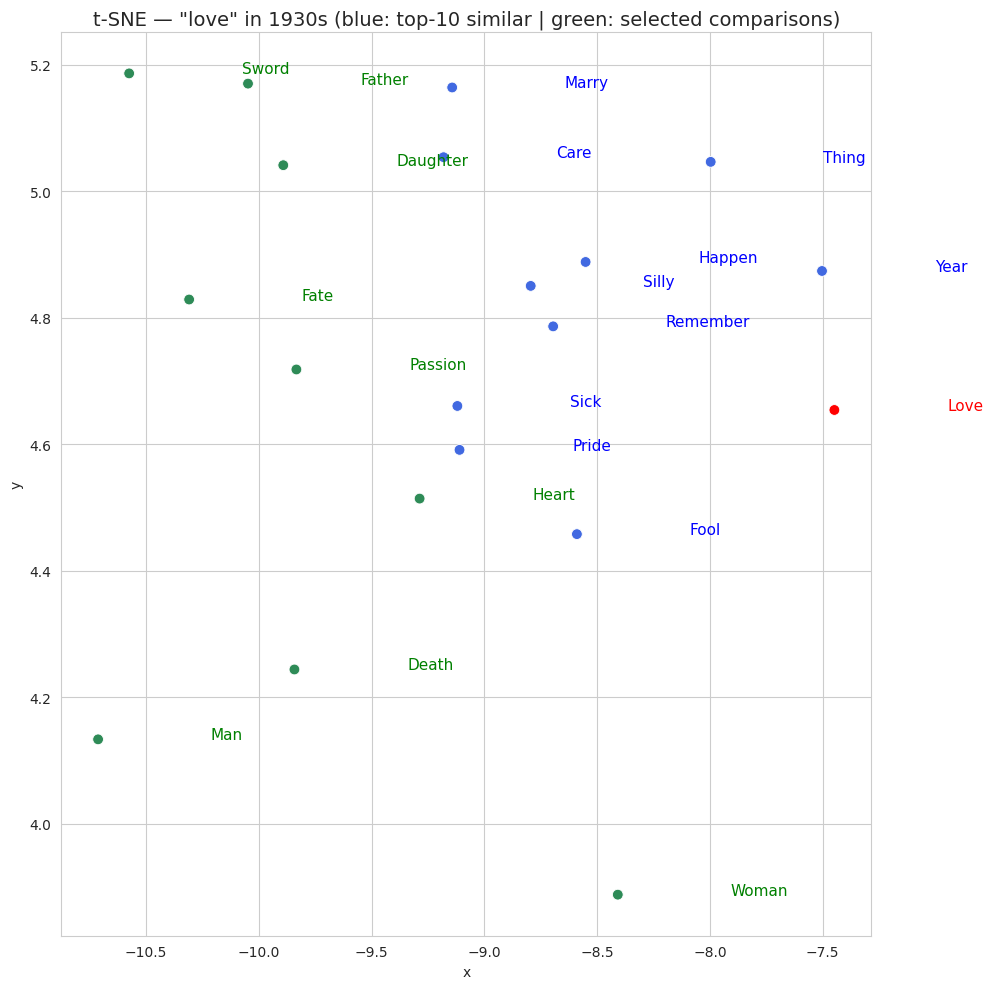

In [128]:
#display plots directly inside the notebook
%matplotlib inline

def tsnescatterplot(model, word, list_names, title=None):
    """
    Create a t-SNE visualization for:
    - the target word (shown in red)
    - its top 10 most similar words (shown in blue)
    - additional comparison words from `list_names` (shown in green)
    """

    #get the embedding vector size from the Word2Vec model
    dim = model.wv.vector_size

    #initialize arrays and metadata containers
    arrays = np.empty((0, dim), dtype='f')
    word_labels = [word]
    color_list = ['red']

    #add the vector for the target/query word
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    #retrieve and add the top 10 most similar words
    for wrd, _ in model.wv.most_similar([word], topn=10):

        #append the word vector
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)

        #store label and display color
        word_labels.append(wrd)
        color_list.append('blue')

    #add comparison words from the provided list
    #ignore words that are not in the vocabulary (OOV = Out Of Vocabulary)
    for wrd in list_names:
        if wrd in model.wv:

            #append the word vector
            arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)

            #store label and display color
            word_labels.append(wrd)
            color_list.append('green')

    # Dimensionality reduction

    # First reduce dimensions using PCA
    # Limit PCA dimensions to:
    # 50 maximum
    # number of samples - 1
    # original embedding dimension
    n_pca = min(50, arrays.shape[0] - 1, dim)

    reduc = PCA(n_components=n_pca).fit_transform(arrays)

    #set perplexity for t-SNE
    #must be smaller than the number of samples
    perp = min(15, reduc.shape[0] - 1)

    #reduce to 2D using t-SNE
    Y = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perp
    ).fit_transform(reduc)

    #create a DataFrame for plotting
    df_plot = pd.DataFrame({
        'x': Y[:, 0],
        'y': Y[:, 1],
        'words': word_labels,
        'color': color_list
    })

    # Plotting

    #create figure and axes
    fig, ax = plt.subplots(figsize=(10, 10))

    #draw scatter plot
    sns.scatterplot(
        data=df_plot,
        x='x',
        y='y',
        hue='color',
        palette={
            'red': 'red',
            'blue': 'royalblue',
            'green': 'seagreen'
        },
        s=60,
        legend=False,
        ax=ax
    )

    #add text labels next to each point
    for _, row in df_plot.iterrows():
        ax.text(
            row['x'] + 0.5,
            row['y'],
            row['words'].title(),
            fontsize=11,
            color=row['color'],
            weight='normal'
        )

    #set plot title
    ax.set_title(title or f't-SNE — "{word}"', fontsize=14)

    #improve spacing
    plt.tight_layout()

    #display the plot
    plt.show()


# Define the decades to compare and a common set of comparison words
# Using the global variables defined at the beginning of the notebook
decade1_compare = decade1
decade2_compare = decade2

query_word_decade_compare = query_word

comparison_words_for_decades = [
    'honour', 'fate', 'man', 'woman', 'daughter', 'father', 'sword', 'death', 'passion', 'hero', 'villain', 'heart', 'sacred'
]

print(f"Comparing t-SNE clusters for '{query_word_decade_compare}' between the {decade1_compare}s and {decade2_compare}s.")

# Plot for the first decade
if decade1_compare in models:
    tsnescatterplot(
        models[decade1_compare],
        word=query_word_decade_compare,
        list_names=comparison_words_for_decades,
        title=f't-SNE — "{query_word_decade_compare}" in {decade1_compare}s (blue: top-10 similar | green: selected comparisons)'
    )
else:
    print(f"No model found for the {decade1_compare}s.")

# Plot for the second decade
if decade2_compare in models:
    tsnescatterplot(
        models[decade2_compare],
        word=query_word_decade_compare,
        list_names=comparison_words_for_decades,
        title=f't-SNE — "{query_word_decade_compare}" in {decade2_compare}s (blue: top-10 similar | green: selected comparisons)'
    )
else:
    print(f"No model found for the {decade2_compare}s.")


1830s Context Words
shows the words most similar to love in the 1830s model. Nearby words such as heart, mother, wife, and girl suggest that “love” appears in emotional, familial, and romantic contexts in this decade.
1930s Context Words
shows the words most similar to “love” in the 1930s model. Words such as marry, remember, care, fool, and pride suggest that love appears in more conversational, social, and relationship-based contexts.

In [129]:
def get_most_similar_from_dict(query_vector, vector_dict, topn=10, exclude_word=None):
    """
    Finds the most similar words to a query vector within a dictionary of word vectors.
    """
    similarities = []
    query_norm = np.linalg.norm(query_vector)
    if query_norm == 0:
        return []

    for word, vec in vector_dict.items():
        if word == exclude_word:
            continue
        vec_norm = np.linalg.norm(vec)
        if vec_norm == 0:
            continue
        similarity = np.dot(query_vector, vec) / (query_norm * vec_norm)
        similarities.append((word, similarity))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topn]

In [96]:
def tsne_aligned_comparison_plot(
    base_wv, # KeyedVectors object for the base model (e.g., models[decade1].wv)
    aligned_wv_dict, # Dictionary of aligned word vectors for the second model
    query_word,
    common_word_context_list=None,
    title=None,
    topn=10
):
    """
    Creates a t-SNE visualization comparing a query word and its neighbors
    from a base Word2Vec model and its aligned counterpart in another space.

    Args:
        base_wv (gensim.models.keyedvectors.KeyedVectors): Word vectors from the base model.
        aligned_wv_dict (dict): Dictionary of aligned word vectors for the comparison model.
        query_word (str): The word to center the comparison around.
        common_word_context_list (list, optional): List of additional words to include for context.
                                                    Defaults to None.
        title (str, optional): Title for the plot. Defaults to None.
        topn (int, optional): Number of most similar words to retrieve. Defaults to 10.
    """
    dim = base_wv.vector_size # Get the dimensionality of the word vectors
    arrays = []             # List to store word vectors for dimensionality reduction
    word_labels = []        # List to store corresponding word labels for plotting
    color_list = []         # List to store colors for each word based on its category

    # 1. Add query_word from base_wv (red)
    if query_word in base_wv:
        arrays.append(base_wv[query_word])
        word_labels.append(query_word + " (Base)") # Label for the query word in the base model
        color_list.append('red') # Assign red color
    else:
        print(f"'{query_word}' not in base vocabulary.")
        return # Exit if the query word is not found in the base model

    # 2. Add top N similar words to query_word from base_wv (blue)
    try:
        for wrd, _ in base_wv.most_similar([query_word], topn=topn):
            arrays.append(base_wv[wrd])
            word_labels.append(wrd + " (Base)") # Label for similar words in the base model
            color_list.append('blue') # Assign blue color
    except KeyError:
        print(f"No similar words found for '{query_word}' in base vocabulary.")

    # 3. Add aligned vector for query_word from aligned_wv_dict (orange)
    if query_word in aligned_wv_dict:
        arrays.append(aligned_wv_dict[query_word])
        word_labels.append(query_word + " (Aligned)") # Label for the query word in the aligned model
        color_list.append('orange') # Assign orange color

        # 4. Add top N words most similar to the aligned query_word within aligned_wv_dict (purple)
        aligned_query_vector = aligned_wv_dict[query_word]
        # Use the helper function to find similar words in the aligned space
        similar_aligned_words = get_most_similar_from_dict(aligned_query_vector, aligned_wv_dict, topn=topn, exclude_word=query_word)
        for wrd, _ in similar_aligned_words:
            arrays.append(aligned_wv_dict[wrd])
            word_labels.append(wrd + " (Aligned)") # Label for similar words in the aligned model
            color_list.append('purple') # Assign purple color
    else:
        print(f"'{query_word}' not in aligned vocabulary.")

    # 5. Add common_word_context_list words from base_wv (light blue) and aligned (light green)
    if common_word_context_list:
        for common_wrd in common_word_context_list:
            if common_wrd in base_wv:
                arrays.append(base_wv[common_wrd])
                word_labels.append(common_wrd + " (Base-Ctx)") # Label for context words in base model
                color_list.append('lightblue') # Assign light blue color
            if common_wrd in aligned_wv_dict:
                arrays.append(aligned_wv_dict[common_wrd])
                word_labels.append(common_wrd + " (Aligned-Ctx)") # Label for context words in aligned model
                color_list.append('lightgreen') # Assign light green color

    arrays = np.array(arrays) # Convert list of vectors to a NumPy array for processing

    if arrays.shape[0] < 2:
        print("Not enough data points to create a t-SNE plot.")
        return # Exit if there aren't enough data points for plotting

    # --- Dimensionality reduction ---
    # First, apply PCA to reduce the dimensions to a more manageable size (max 50) before t-SNE.
    # This helps t-SNE converge better, especially with high-dimensional data.
    n_pca = min(50, arrays.shape[0] - 1, dim)
    reduc = PCA(n_components=n_pca, random_state=42).fit_transform(arrays)

    # Set perplexity for t-SNE. It must be less than the number of samples minus 1.
    # Perplexity relates to the number of nearest neighbors t-SNE considers.
    perp = min(15, reduc.shape[0] - 1)

    # If perplexity is too low (less than 2), t-SNE cannot be performed effectively.
    # In such cases, fall back to PCA for a direct 2D projection.
    if perp < 2: # t-SNE requires perplexity > 1
        print(f"Not enough data points (n={reduc.shape[0]}) for t-SNE with perplexity > 1. Falling back to PCA for 2D visualization.")
        # Fallback to PCA if not enough points for TSNE
        if arrays.shape[0] >= 2:
            Y = PCA(n_components=2, random_state=42).fit_transform(arrays) # Directly reduce to 2D using PCA
        else:
            print("Cannot visualize with less than 2 data points even with PCA.")
            return # Exit if even PCA to 2D is not possible
    else:
        # Apply t-SNE to further reduce the PCA-transformed data to 2 dimensions for visualization.
        # 'metric="cosine"' is often suitable for word embeddings.
        Y = TSNE(n_components=2, random_state=42, perplexity=perp, metric='cosine').fit_transform(reduc)

    # Create a Pandas DataFrame for easy plotting with seaborn.
    df_plot = pd.DataFrame({
        'x': Y[:, 0], # First t-SNE dimension
        'y': Y[:, 1], # Second t-SNE dimension
        'words': word_labels, # Word labels
        'color': color_list # Colors for each word category
    })

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 12)) # Create a figure and a set of subplots
    sns.scatterplot(
        data=df_plot,
        x='x',
        y='y',
        hue='color', # Differentiate points by color category
        palette={ # Define the color palette for each category
            'red': 'red',          # Base Query Word
            'blue': 'royalblue',   # Base Similar Words
            'orange': 'orange',    # Aligned Query Word
            'purple': 'darkorchid',# Aligned Similar Words
            'lightblue': 'lightblue', # Base Context Words
            'lightgreen': 'lightgreen' # Aligned Context Words
        },
        s=80, # Size of the scatter points
        legend='full', # Display the full legend
        ax=ax # Plot on the created axes
    )

    # Add text labels next to each point for better identification
    for _, row in df_plot.iterrows():
        ax.text(
            row['x'] + 0.3, # Offset x-coordinate slightly for text readability
            row['y'],       # Y-coordinate
            row['words'],   # The word label itself
            fontsize=9,
            color=row['color'],
            weight='normal'
        )

    # Set the title of the plot, using a provided title or a default one.
    ax.set_title(title or f't-SNE Aligned Comparison for "{query_word}"', fontsize=16)
    plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping
    plt.show() # Display the plot

## Add Procrustes alignment

In [130]:
from scipy.linalg import orthogonal_procrustes

In [131]:
# Choose two decades for comparison
decade1_align = decade1
decade2_align = decade2

# Ensure both models exist
if decade1_align not in models:
    print(f"Model for {decade1_align}s not found.")
elif decade2_align not in models:
    print(f"Model for {decade2_align}s not found.")
else:
    model1 = models[decade1_align].wv
    model2 = models[decade2_align].wv

    print(f"Comparing models from {decade1_align}s and {decade2_align}s.")

    # Find common words present in both vocabularies
    common_words = list(set(model1.key_to_index.keys()) & set(model2.key_to_index.keys()))
    print(f"Found {len(common_words)} common words between the two decades.")

    if len(common_words) < 2:
        print("Not enough common words to perform alignment.")
    else:
        # Extract vectors for common words
        vectors1 = np.array([model1[word] for word in common_words])
        vectors2 = np.array([model2[word] for word in common_words])

        # Perform orthogonal Procrustes alignment
        # M: transformation matrix to apply to vectors2 to align them with vectors1
        # c: scaling factor
        R, sc = orthogonal_procrustes(vectors1, vectors2)

        # Apply the transformation to the second set of vectors
        aligned_vectors2 = vectors2 @ R * sc

        print("Procrustes alignment completed.")

        # Now, we can compare similarities in the aligned space
        # Let's take a few example words and see their nearest neighbors in the aligned space

        # Create a dictionary for easier lookup of aligned vectors
        aligned_model2_dict = {word: aligned_vectors2[i] for i, word in enumerate(common_words)}
        model1_dict = {word: vectors1[i] for i, word in enumerate(common_words)}

        print(f"\nTop 5 similar words for '{query_word}' in {decade2_align}s after alignment to {decade1_align}s:")

        # Find the vector for 'love' from model1 to use as query
        if query_word in model1_dict and query_word in aligned_model2_dict:
            query_vector = model1_dict[query_word]

            # Calculate cosine similarity with all aligned vectors from model2
            similarities = []
            for word_item, vec in aligned_model2_dict.items():
                # Compute cosine similarity between query_vector and current word's aligned vector
                # Handle zero norm vectors to avoid division by zero
                query_norm = np.linalg.norm(query_vector)
                vec_norm = np.linalg.norm(vec)
                if query_norm == 0 or vec_norm == 0:
                    similarity = 0.0 # Or handle as appropriate for your data
                else:
                    similarity = np.dot(query_vector, vec) / (query_norm * vec_norm)
                similarities.append((word_item, similarity))

            # Sort by similarity and print top 5
            similarities.sort(key=lambda x: x[1], reverse=True)
            for word_item, sim in similarities[:5]:
                print(f"  {word_item:<15} {sim:.4f}")
        else:
            print(f"'{query_word}' not in vocabulary of one or both models for alignment test.")


Comparing models from 1830s and 1930s.
Found 1461 common words between the two decades.
Procrustes alignment completed.

Top 5 similar words for 'love' in 1930s after alignment to 1830s:
  stair           0.6548
  island          0.6533
  nod             0.6528
  clutch          0.6518
  problem         0.6515


Generating aligned t-SNE plot for 'love' between 1830s and 1930s.


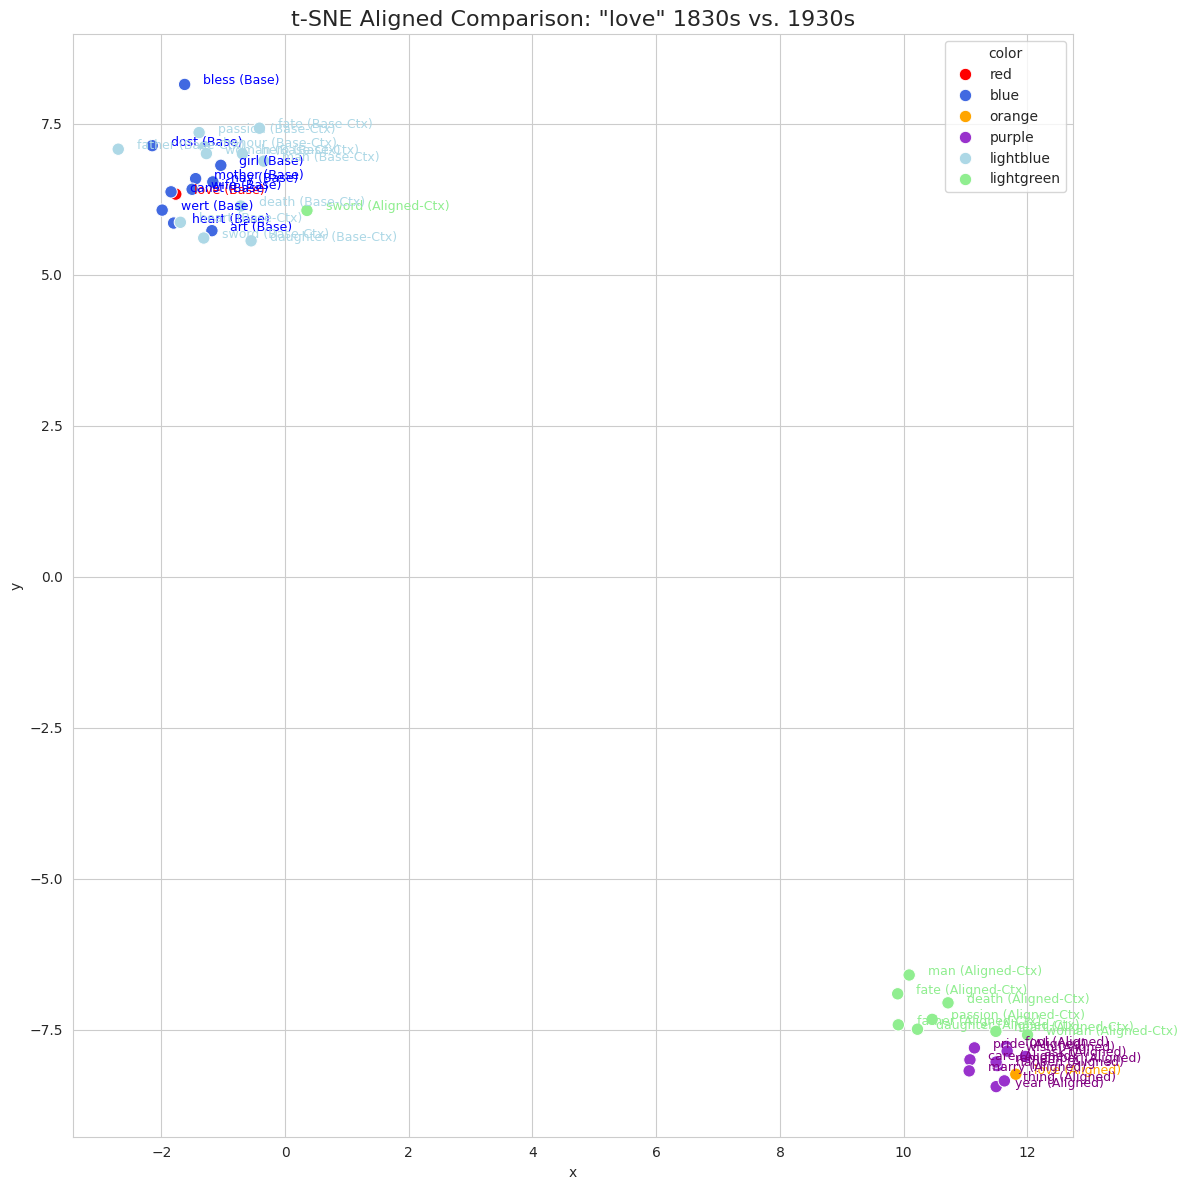

In [132]:
# Define decades and a query word for the aligned comparison plot
align_decade1 = decade1
align_decade2 = decade2
align_query_word = query_word

align_comparison_words = [
    'honour', 'fate', 'man', 'woman', 'daughter', 'father', 'sword', 'death', 'passion', 'hero', 'villain', 'heart', 'sacred'
]

# Ensure models and aligned_model2_dict are available from previous steps
if align_decade1 in models and align_decade2 in models and 'aligned_model2_dict' in locals():
    print(f"Generating aligned t-SNE plot for '{align_query_word}' between {align_decade1}s and {align_decade2}s.")
    tsne_aligned_comparison_plot(
        base_wv=models[align_decade1].wv,
        aligned_wv_dict=aligned_model2_dict,
        query_word=align_query_word,
        common_word_context_list=align_comparison_words,
        title=f't-SNE Aligned Comparison: "{align_query_word}" {align_decade1}s vs. {align_decade2}s'
    )
else:
    print("Could not generate aligned t-SNE plot. Ensure models are trained and Procrustes alignment has been performed.")


compares the semantic neighborhood of lovebetween the 1830s and 1930s after alignment. The visualization attempts to place words from both decades into a shared space so their relationships can be compared. The separation between clusters suggests that the contexts around love differed between the two decades.

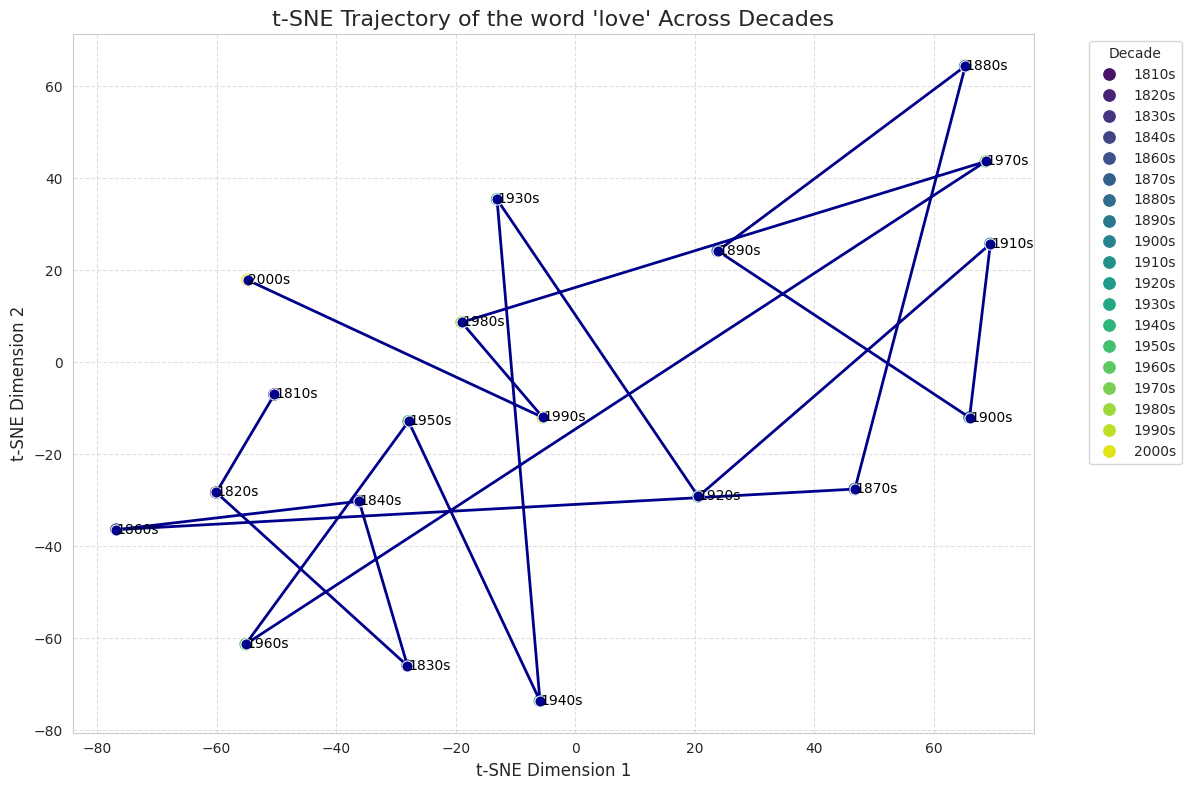

In [133]:
word_vectors, word_decade_labels = collect_word_vectors_across_decades(models, query_word)

# Check if any word vectors were found across the decades
if not word_vectors.size:
    print(f"No '{query_word}' vectors found across any decade. Cannot create trajectory plot.")
else:
    # Convert the list of word vectors into a NumPy array for processing
    word_vectors_array = np.array(word_vectors)

    n_components_pca = min(50, word_vectors_array.shape[0] - 1, word_vectors_array.shape[1])

    if n_components_pca < 2:
        print("Not enough data points or dimensions for PCA reduction. Attempting t-SNE directly.")
        reduced_vectors = word_vectors_array # Skip PCA if not enough components
    else:
        # Initialize and apply PCA to reduce dimensions
        pca = PCA(n_components=n_components_pca, random_state=42)
        reduced_vectors = pca.fit_transform(word_vectors_array)

    perplexity_val = min(5, reduced_vectors.shape[0] - 1)

    if perplexity_val < 1:
        print("Not enough data points for t-SNE with perplexity. Using PCA for 2D.")
        if reduced_vectors.shape[0] >= 2:
            # Use PCA to project directly to 2D if t-SNE is not feasible
            tsne_results = PCA(n_components=2, random_state=42).fit_transform(word_vectors_array)
        else:
            print("Cannot create trajectory plot with less than 2 data points.")
            tsne_results = None # No visualization possible
    else:
        # Initialize and apply t-SNE to further reduce to 2 dimensions for plotting
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, metric='cosine')
        tsne_results = tsne.fit_transform(reduced_vectors)

    if tsne_results is not None:
        # Create a Pandas DataFrame to hold the 2D coordinates and decade labels
        df_trajectory = pd.DataFrame({
            'x': tsne_results[:, 0],
            'y': tsne_results[:, 1],
            'decade': word_decade_labels
        })

        # Use the reusable plot_trajectory function
        plot_trajectory(
            df=df_trajectory,
            line_color='darkblue',
            scatter_palette='viridis',
            title=f"t-SNE Trajectory of the word '{query_word}' Across Decades",
            xlabel="t-SNE Dimension 1",
            ylabel="t-SNE Dimension 2",
            text_prefix=''
        )

Score	Meaning
1.0	almost identical context
0.5	somewhat related
0	unrelated
negative	opposite contexts

t-SNE plot visualizes the position of love across decades in a lower-dimensional space. The line connects the decades in chronological order, showing possible shifts in the word’s usage. However, t-SNE can exaggerate distances, so this plot should be interpreted as a visual pattern rather than exact evidence of semantic change.

### PCA Trajectory of the word 'love' Across Decades

raw Word2Vec vectors

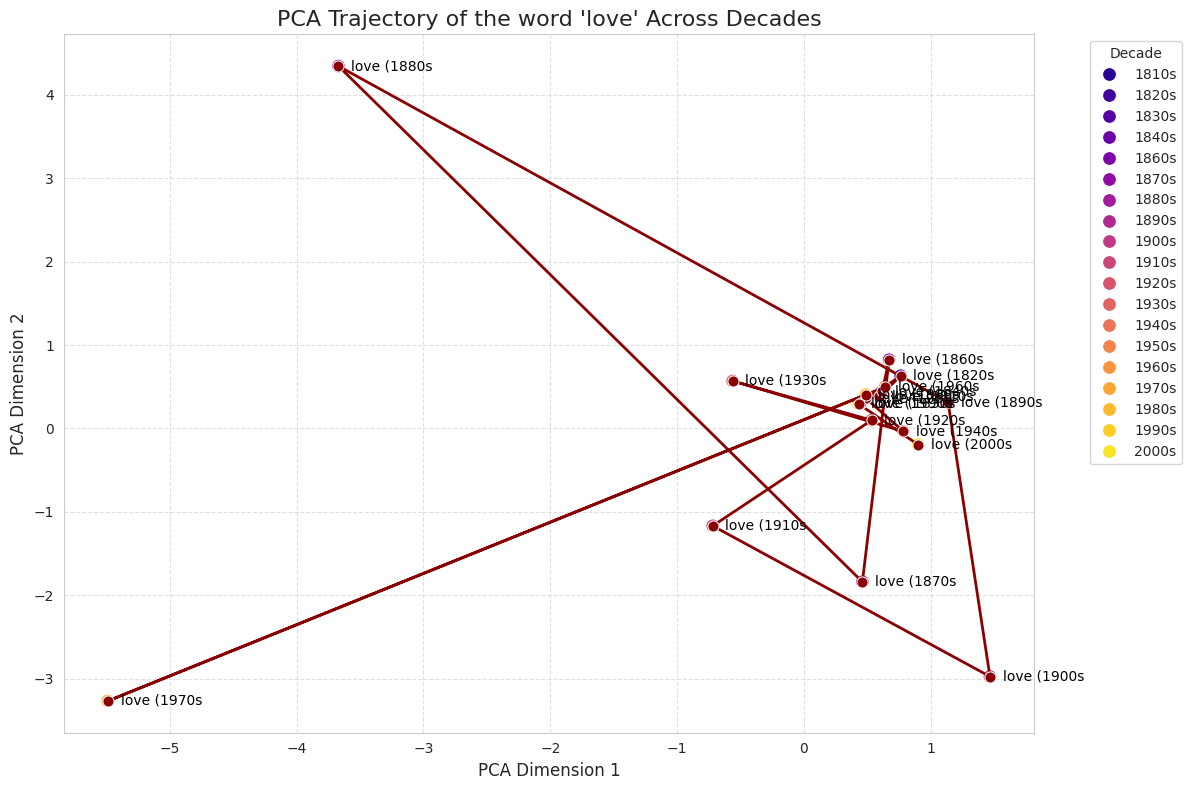

In [134]:
# Prepare data for '{query_word}' trajectory
word_vectors_pca, word_decade_labels_pca = collect_word_vectors_across_decades(models, query_word)

if not word_vectors_pca.size:
    print(f"No '{query_word}' vectors found across any decade. Cannot create PCA trajectory plot.")
elif word_vectors_pca.shape[0] < 2 or word_vectors_pca.shape[1] < 2:
    print("Not enough data points or dimensions for PCA 2D visualization.")
else:
    # Convert to numpy array
    word_vectors_array_pca = np.array(word_vectors_pca)

    # Apply PCA for 2D visualization
    pca_word = PCA(n_components=2, random_state=42)
    pca_results_word = pca_word.fit_transform(word_vectors_array_pca)

    df_trajectory_pca = pd.DataFrame({
        'x': pca_results_word[:, 0],
        'y': pca_results_word[:, 1],
        'decade': word_decade_labels_pca
    })

    # Use the reusable plot_trajectory function
    plot_trajectory(
        df=df_trajectory_pca,
        line_color='darkred',
        scatter_palette='plasma',
        title=f"PCA Trajectory of the word '{query_word}' Across Decades",
        xlabel="PCA Dimension 1",
        ylabel="PCA Dimension 2",
        text_prefix=f'{query_word} (' # Add prefix for text labels if desired
    )

shows the raw PCA trajectory of love across decades before alignment. Each point represents the word love in a separate decade model. Because the Word2Vec models were trained independently, this plot is useful for exploration but may be misleading if interpreted as direct semantic movement.

In [135]:
def align_models_to_reference(models, reference_decade):
    """
    Align all Word2Vec models to the vector space of one reference decade.
    Returns a dictionary:
        aligned_vectors_by_decade[decade][word] = aligned vector
    """
    reference_wv = models[reference_decade].wv
    aligned_vectors_by_decade = {}

    for decade, model in models.items():
        current_wv = model.wv

        common_words = list(
            set(reference_wv.key_to_index.keys()) &
            set(current_wv.key_to_index.keys())
        )

        if len(common_words) < 2:
            print(f"Skipping {decade}s: not enough shared vocabulary.")
            continue

        reference_vectors = np.array([reference_wv[word] for word in common_words])
        current_vectors = np.array([current_wv[word] for word in common_words])

        if decade == reference_decade:
            aligned_vectors = current_vectors
        else:
            rotation_matrix, _ = orthogonal_procrustes(current_vectors, reference_vectors)
            aligned_vectors = current_vectors @ rotation_matrix

        aligned_vectors_by_decade[decade] = {
            word: aligned_vectors[i]
            for i, word in enumerate(common_words)
        }

    return aligned_vectors_by_decade

In [136]:
def collect_aligned_word_vectors(aligned_vectors_by_decade, word):
    vectors = []
    labels = []

    for decade in sorted(aligned_vectors_by_decade.keys()):
        if word in aligned_vectors_by_decade[decade]:
            vectors.append(aligned_vectors_by_decade[decade][word])
            labels.append(f"{decade}s")

    return np.array(vectors), labels

aligned vectors

In [137]:
reference_decade = decade1

aligned_vectors_by_decade = align_models_to_reference(
    models=models,
    reference_decade=reference_decade
)

aligned_word_vectors, aligned_decade_labels = collect_aligned_word_vectors(
    aligned_vectors_by_decade,
    query_word
)

if len(aligned_word_vectors) < 2:
    print(f"Not enough aligned vectors for '{query_word}'.")
else:
    pca = PCA(n_components=2, random_state=42)
    pca_results = pca.fit_transform(aligned_word_vectors)

    df_aligned_pca = pd.DataFrame({
        "x": pca_results[:, 0],
        "y": pca_results[:, 1],
        "decade": aligned_decade_labels
    })

    plot_trajectory(
        df=df_aligned_pca,
        title=f"Aligned PCA Trajectory of '{query_word}' Across Decades",
        xlabel="Aligned PCA Dimension 1",
        ylabel="Aligned PCA Dimension 2",
        label_prefix=f"{query_word} "
    )

TypeError: plot_trajectory() got an unexpected keyword argument 'label_prefix'

This plot shows the movement of the word “love” across decades after aligning the Word2Vec models into a shared space. Each point represents “love” in one decade, and the connecting line shows how its position changes over time. This aligned version is more reliable than the raw PCA plot because it makes the decade models more comparable.

## Neighborhood plot

## Global Context Word Similarity (All Decades Combined)

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

similarity helper

In [139]:
def cosine_similarity(vec1, vec2):
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return np.dot(vec1, vec2) / (norm1 * norm2)

In [140]:
reference_decade = decade1

# Ensure models are aligned to a common space
aligned_vectors_by_decade = align_models_to_reference(
    models=models,
    reference_decade=reference_decade
)

all_similarities = []

if query_word not in aligned_vectors_by_decade[reference_decade]:
    print(f"'{query_word}' not found in the reference decade ({reference_decade}s) after alignment.")
else:
    # Get the query word's vector from the reference decade
    query_word_vector_ref = aligned_vectors_by_decade[reference_decade][query_word]

    # Iterate through all decades and words in the aligned space
    for decade, decade_vectors in aligned_vectors_by_decade.items():
        for word, vector in decade_vectors.items():
            # Avoid comparing the word to itself in the reference decade
            if word == query_word and decade == reference_decade:
                continue

            similarity = cosine_similarity(query_word_vector_ref, vector)
            all_similarities.append((word, similarity))

    # Sort by similarity in descending order and get unique words
    # If a word appears in multiple decades, take the highest similarity score
    unique_similarities = {}
    for word, score in all_similarities:
        if word not in unique_similarities or score > unique_similarities[word]:
            unique_similarities[word] = score

    sorted_results = sorted(unique_similarities.items(), key=lambda x: x[1], reverse=True)

    print(f"Top 15 words most similar to '{query_word}' across all aligned decades (relative to {reference_decade}s):")
    for word, score in sorted_results[:15]:
        print(f"  {word:<20} {score:.4f}")

Top 15 words most similar to 'love' across all aligned decades (relative to 1830s):
  honest               0.9378
  saint                0.9363
  breathe              0.9362
  conscious            0.9349
  secret               0.9283
  hate                 0.9283
  ha                   0.9254
  sin                  0.9252
  sage                 0.9239
  mother               0.9236
  wicked               0.9217
  pure                 0.9199
  noble                0.9177
  tender               0.9174
  miserable            0.9169


Align one comparison decade to the reference decade

In [141]:
def most_similar_in_aligned_decade(aligned_vectors_by_decade, decade, query_word, topn=8):
    if decade not in aligned_vectors_by_decade:
        return []

    vector_dict = aligned_vectors_by_decade[decade]

    if query_word not in vector_dict:
        return []

    query_vector = vector_dict[query_word]
    similarities = []

    for word, vec in vector_dict.items():
        if word == query_word:
            continue

        score = cosine_similarity(query_vector, vec)
        similarities.append((word, score))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topn]

Combined plot: trajectory + context words

In [144]:
def plot_trajectory_with_context(
    aligned_vectors_by_decade,
    query_word,
    context_decades,
    topn=8
):
    rows = []

    #add the main word trajectory across ALL decades
    available_decades = sorted(aligned_vectors_by_decade.keys())

    for decade in available_decades:
        decade_dict = aligned_vectors_by_decade[decade]
        if query_word in decade_dict:
            rows.append({
                "word": query_word,
                "decade": decade,
                "kind": "main",
                "label": f"{query_word} {decade}s",
                "vector": decade_dict[query_word]
            })

    # add context words for selected decades only
    for decade in context_decades:
        neighbors = most_similar_in_aligned_decade(
            aligned_vectors_by_decade,
            decade,
            query_word,
            topn=topn
        )

        for word, score in neighbors:
            rows.append({
                "word": word,
                "decade": decade,
                "kind": "context",
                "label": f"{word} ({decade}s)",
                "vector": aligned_vectors_by_decade[decade][word],
                "score": score
            })

    if len(rows) < 2:
        print("Not enough data to plot.")
        return

    # ONE PCA for everything together
    all_vectors = np.array([row["vector"] for row in rows])

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(all_vectors)

    df = pd.DataFrame({
        "x": coords[:, 0],
        "y": coords[:, 1],
        "word": [row["word"] for row in rows],
        "decade": [row["decade"] for row in rows],
        "kind": [row["kind"] for row in rows],
        "label": [row["label"] for row in rows]
    })

    #plot
    plt.figure(figsize=(14, 10))

    #plot the main trajectory line
    main_df = df[df["kind"] == "main"].sort_values("decade")

    plt.plot(
        main_df["x"],
        main_df["y"],
        marker="o",
        linewidth=2,
        label=f"Trajectory of '{query_word}'"
    )

    #label the main word points
    for _, row in main_df.iterrows():
        plt.text(
            row["x"] + 0.03,
            row["y"] + 0.03,
            row["label"],
            fontsize=10,
            weight="bold"
        )

    # plot context words for each selected decade
    colors = ["tab:green", "tab:red", "tab:purple", "tab:orange"]
    decade_color_map = {}

    for i, decade in enumerate(context_decades):
        decade_color_map[decade] = colors[i % len(colors)]

    for decade in context_decades:
        subset = df[(df["kind"] == "context") & (df["decade"] == decade)]

        if subset.empty:
            continue

        plt.scatter(
            subset["x"],
            subset["y"],
            s=80,
            color=decade_color_map[decade],
            label=f"{decade}s context words"
        )

        # label context words
        for _, row in subset.iterrows():
            plt.text(
                row["x"] + 0.02,
                row["y"] + 0.02,
                row["label"],
                fontsize=9,
                color=decade_color_map[decade]
            )

        # connect each context word to the main word of that decade
        main_point = main_df[main_df["decade"] == decade]
        if not main_point.empty:
            main_x = main_point.iloc[0]["x"]
            main_y = main_point.iloc[0]["y"]

            for _, row in subset.iterrows():
                plt.plot(
                    [main_x, row["x"]],
                    [main_y, row["y"]],
                    linestyle="--",
                    linewidth=1,
                    alpha=0.5,
                    color=decade_color_map[decade]
                )

    plt.title(f"Aligned Trajectory + Context Words for '{query_word}'")
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

Run

shows how the word love changes across decades after aligning the Word2Vec models. The blue line traces the movement of love over time, while the green and red points show the words most closely associated with love in the 1830s and 1930s. The comparison suggests that love had a more emotional and literary context in the 1830s, while its 1930s context appears more conversational and relationship-based.

In [145]:
#Configure Target Word and Decades
query_word = "love" # @param {type:"string"}
decade1 = 1830 # @param {type:"integer"}
decade2 = 1930 # @param {type:"integer"}

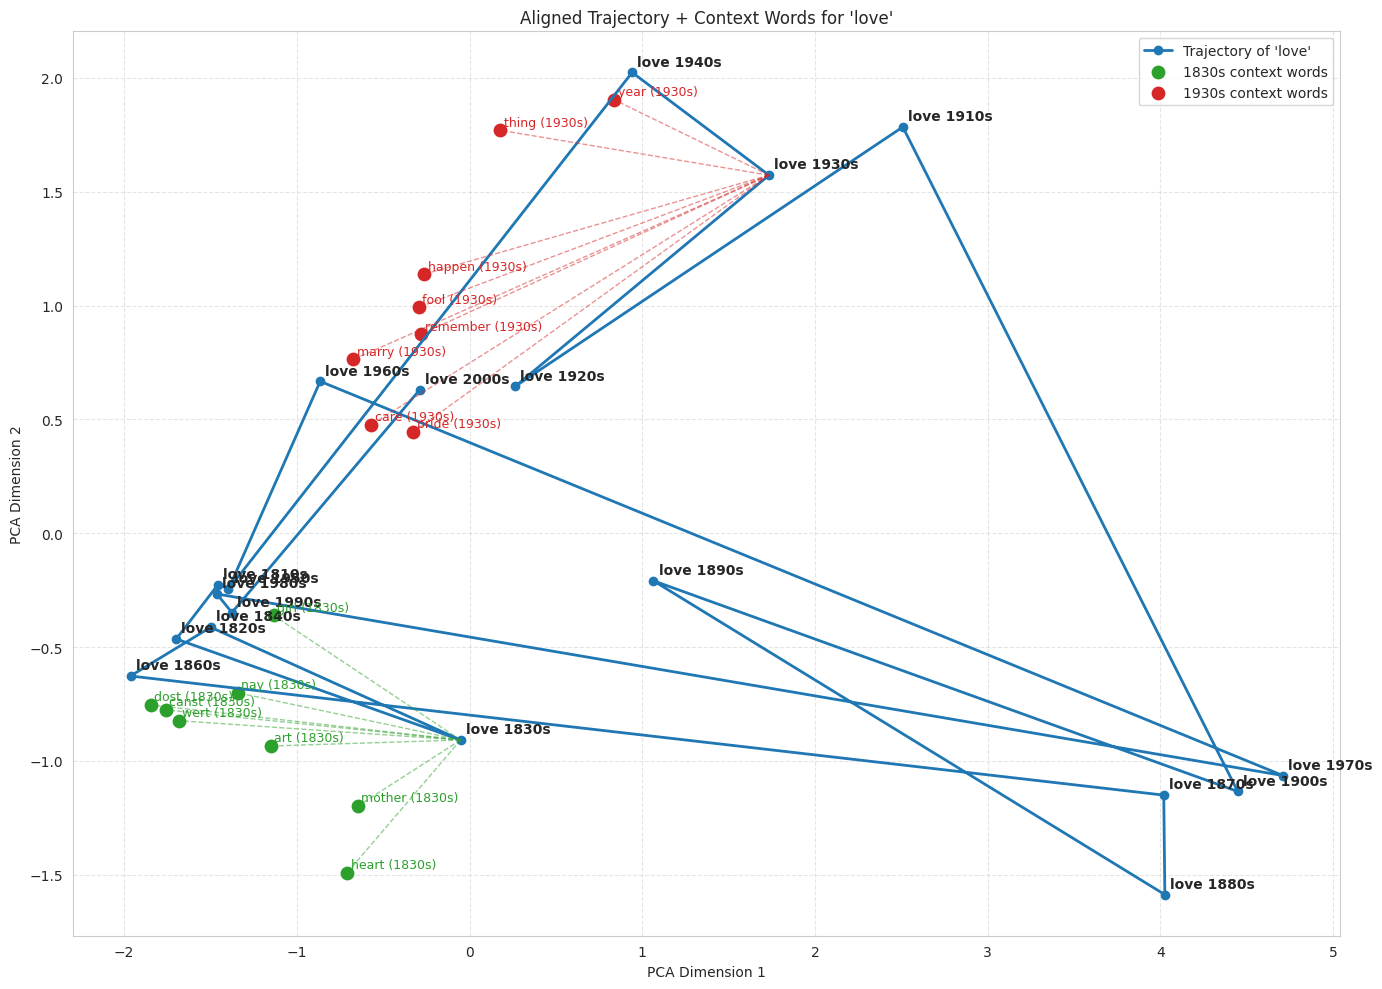

In [143]:
# Use the global configuration values
reference_decade = decade1
context_decades = [decade1, decade2]

aligned_vectors_by_decade = align_models_to_reference(
    models=models,
    reference_decade=reference_decade
)

plot_trajectory_with_context(
    aligned_vectors_by_decade=aligned_vectors_by_decade,
    query_word=query_word,
    context_decades=context_decades,
    topn=8
)

## All Decades Combined: Trajectory + Context Words

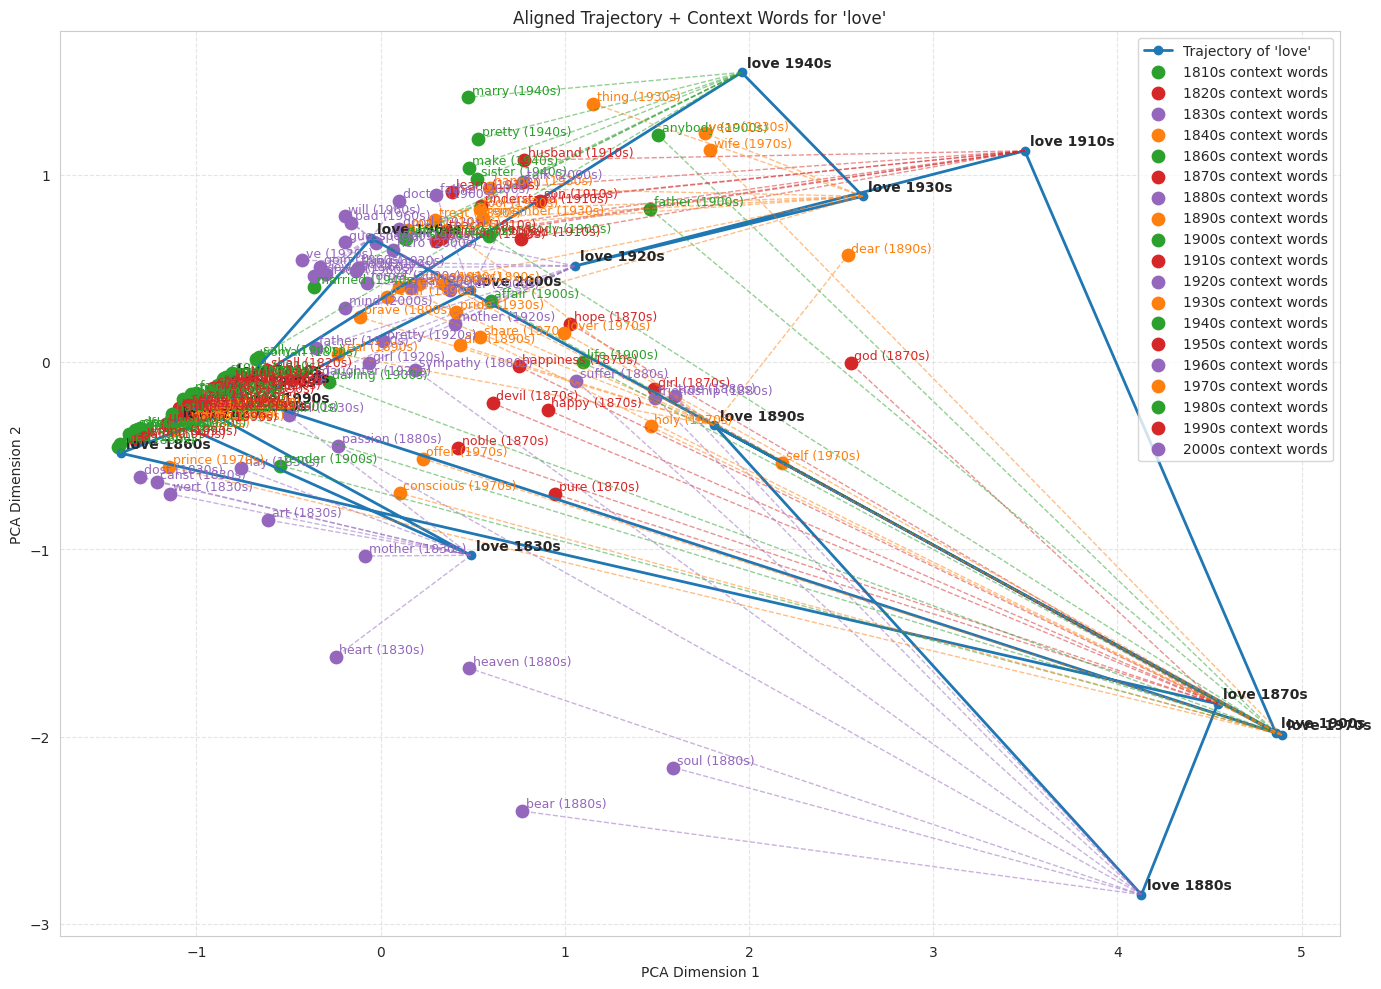

In [146]:
#get all available decades from the aligned models
all_available_decades = sorted(aligned_vectors_by_decade.keys())

#set context_decades to include all available decades
context_decades_all = all_available_decades

plot_trajectory_with_context(
    aligned_vectors_by_decade=aligned_vectors_by_decade,
    query_word=query_word,
    context_decades=context_decades_all,
    topn=8
)